# 💸 LLM Cost & Token Tracker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/llm-cost-tracker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/llm-cost-tracker/demo.ipynb)

Surprise API bills happen because token usage is **invisible until the invoice lands**. This tracker logs every call (model, prompt/completion tokens, cost, tag), estimates tokens offline when a provider count isn't handy, and rolls usage up by model, tag, and day - with a monthly budget check.

**What we cover**
1. Pricing table + per-call cost math
2. Offline token estimation
3. Logging a stream of calls
4. Rollups by model / tag / day
5. 📊 Where the money actually goes
6. Budget check

Fully offline - rates live in an editable table, no network calls.

> Rates below are **example values** for illustration. Edit `PRICING` to match your contract.

## Step 1 - Pricing and per-call cost

Rates are USD per **1,000,000 tokens**, split into input (prompt) and output (completion). Output is typically several times more expensive than input - which changes how you optimize.

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Optional
import math

PRICING = {
    "claude-opus":   {"in": 15.00, "out": 75.00},
    "claude-sonnet": {"in": 3.00,  "out": 15.00},
    "claude-haiku":  {"in": 0.80,  "out": 4.00},
    "gpt-large":     {"in": 5.00,  "out": 15.00},
    "gpt-mini":      {"in": 0.15,  "out": 0.60},
}

def estimate_tokens(text):
    return math.ceil(len(text) / 4) if text else 0

def call_cost(model, prompt_tokens, completion_tokens):
    rate = PRICING[model]
    return round(prompt_tokens/1_000_000*rate["in"] + completion_tokens/1_000_000*rate["out"], 6)

print("One claude-opus call, 4000 in / 1200 out:  $", call_cost("claude-opus", 4000, 1200))
print("One gpt-mini call,    500 in / 150 out:    $", call_cost("gpt-mini", 500, 150))

One claude-opus call, 4000 in / 1200 out:  $ 0.15
One gpt-mini call,    500 in / 150 out:    $ 0.000165


## Step 2 - Offline token estimation

When you didn't instrument a call, estimate from text length (~4 chars/token). Use the provider's real count when you have it; this is the fallback.

In [2]:
sample = "Summarize this 2-page contract in exactly five bullet points."
print(f"'{sample}'")
print("estimated tokens:", estimate_tokens(sample))

'Summarize this 2-page contract in exactly five bullet points.'
estimated tokens: 16


## Step 3 - Log a stream of calls

Each record carries a `tag` (feature/team/route) and a `day` so we can slice spend later. `prompt`/`completion` accept raw text (estimated) or an int token count (used as-is).

In [3]:
@dataclass
class CallRecord:
    model: str; prompt_tokens: int; completion_tokens: int
    cost: float; tag: str = "default"; day: str = "2026-07-01"
    @property
    def total_tokens(self): return self.prompt_tokens + self.completion_tokens

class CostTracker:
    def __init__(self, monthly_budget_usd=None):
        self.records = []; self.monthly_budget_usd = monthly_budget_usd
    def log(self, model, prompt, completion, tag="default", day="2026-07-01"):
        pt = prompt if isinstance(prompt, int) else estimate_tokens(prompt)
        ct = completion if isinstance(completion, int) else estimate_tokens(completion)
        rec = CallRecord(model, pt, ct, call_cost(model, pt, ct), tag, day)
        self.records.append(rec); return rec
    @property
    def total_cost(self): return round(sum(r.cost for r in self.records), 4)
    @property
    def total_tokens(self): return sum(r.total_tokens for r in self.records)
    def _rollup(self, key):
        agg = {}
        for r in self.records:
            k = getattr(r, key)
            a = agg.setdefault(k, {"calls":0,"tokens":0,"cost":0.0})
            a["calls"]+=1; a["tokens"]+=r.total_tokens; a["cost"]+=r.cost
        rows = [{key:k,"calls":int(v["calls"]),"tokens":int(v["tokens"]),"cost_usd":round(v["cost"],4)} for k,v in agg.items()]
        rows.sort(key=lambda x: x["cost_usd"], reverse=True); return rows
    def by_model(self): return self._rollup("model")
    def by_tag(self): return self._rollup("tag")
    def by_day(self):
        rows = self._rollup("day"); rows.sort(key=lambda x: x["day"]); return rows
    def budget_status(self):
        spent = self.total_cost
        if self.monthly_budget_usd is None:
            return {"budget":None,"spent":spent,"pct":None,"over":False}
        pct = round(spent/self.monthly_budget_usd*100,1)
        return {"budget":self.monthly_budget_usd,"spent":spent,"pct":pct,
                "over":spent>self.monthly_budget_usd,"remaining":round(self.monthly_budget_usd-spent,4)}

t = CostTracker(monthly_budget_usd=50.0)
traffic = [
    ("claude-opus", 4000, 1200, "contract-analysis", "2026-07-01", 12),
    ("claude-sonnet", 1500, 600, "chat-support", "2026-07-01", 40),
    ("claude-haiku", 800, 200, "classify-tickets", "2026-07-02", 200),
    ("gpt-large", 2000, 800, "summarize", "2026-07-02", 25),
    ("claude-opus", 4000, 1500, "contract-analysis", "2026-07-03", 10),
    ("gpt-mini", 500, 150, "autocomplete", "2026-07-03", 500),
    ("claude-sonnet", 1500, 700, "chat-support", "2026-07-03", 60),
]
for model, pt, ct, tag, day, n in traffic:
    for _ in range(n): t.log(model, pt, ct, tag=tag, day=day)
print(f"Logged {len(t.records)} calls · {t.total_tokens:,} tokens · ${t.total_cost}")

Logged 847 calls · 928,400 tokens · $5.8855


## Step 4 - Rollups

The punchline: **the cheapest per-call model is rarely the biggest line item.** 500 gpt-mini calls cost less than 22 opus calls. Optimize the total, not the sticker price.

In [4]:
import pandas as pd
print("By model:"); display(pd.DataFrame(t.by_model()))
print("By tag:");   display(pd.DataFrame(t.by_tag()))
print("By day:");   display(pd.DataFrame(t.by_day()))

By model:


,model,calls,tokens,cost_usd
0,claude-opus,22,117400,3.5250
1,claude-sonnet,100,216000,1.4400
2,gpt-large,25,70000,0.5500
3,claude-haiku,200,200000,0.2880
4,gpt-mini,500,325000,0.0825


By tag:


,tag,calls,tokens,cost_usd
0,contract-analysis,22,117400,3.5250
1,chat-support,100,216000,1.4400
2,summarize,25,70000,0.5500
3,classify-tickets,200,200000,0.2880
4,autocomplete,500,325000,0.0825


By day:


,day,calls,tokens,cost_usd
0,2026-07-01,52,146400,2.3400
1,2026-07-02,225,270000,0.8380
2,2026-07-03,570,512000,2.7075


## Step 5 - 📊 Where the money goes

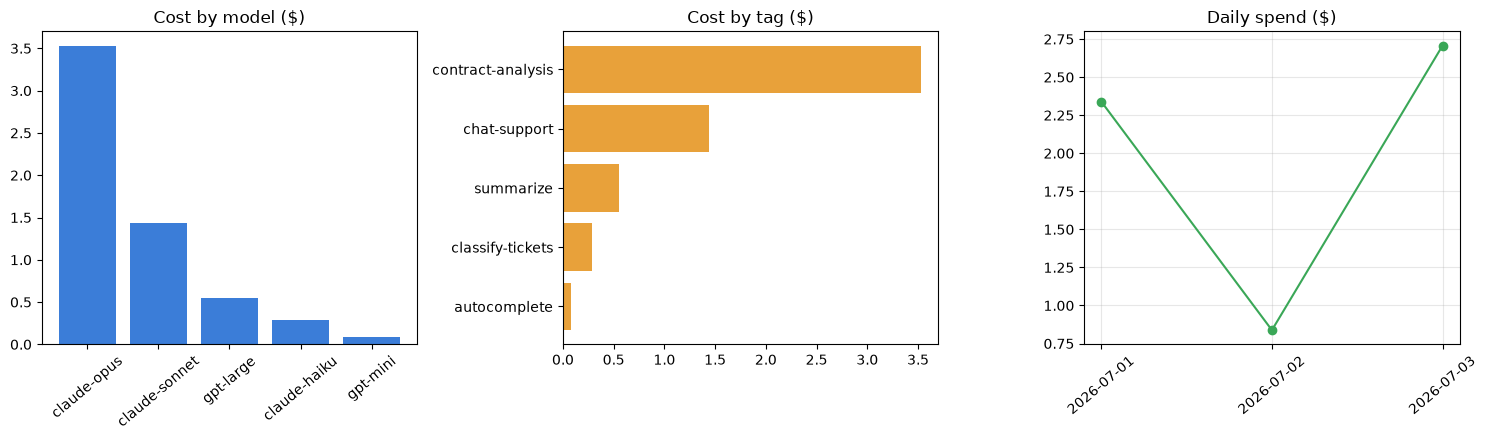

Saved cost_breakdown.png


In [5]:
import matplotlib.pyplot as plt

bm = t.by_model(); bt = t.by_tag(); bd = t.by_day()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

ax1.bar([r["model"] for r in bm], [r["cost_usd"] for r in bm], color="#3b7dd8")
ax1.set_title("Cost by model ($)"); ax1.tick_params(axis="x", rotation=40)

ax2.barh([r["tag"] for r in bt], [r["cost_usd"] for r in bt], color="#e8a13a")
ax2.invert_yaxis(); ax2.set_title("Cost by tag ($)")

ax3.plot([r["day"] for r in bd], [r["cost_usd"] for r in bd], marker="o", color="#3aa757")
ax3.set_title("Daily spend ($)"); ax3.tick_params(axis="x", rotation=40)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cost_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved cost_breakdown.png")

## Step 6 - Budget check

In [6]:
b = t.budget_status()
bar = "█" * int(b["pct"] / 5) + "·" * (20 - int(b["pct"] / 5))
print(f"Budget: ${b['spent']} / ${b['budget']}")
print(f"[{bar}] {b['pct']}%  ->  {'⚠️ OVER BUDGET' if b['over'] else 'within budget'}")
print(f"Remaining: ${b['remaining']}")

Budget: $5.8855 / $50.0
[██··················] 11.8%  ->  within budget
Remaining: $44.1145


## Summary

- **Log every call** with a tag - the tag is what turns "we spent $6" into "contract-analysis is 60% of spend."
- **Output tokens dominate** at 3-5x the input rate; trimming verbose completions often saves more than shrinking prompts.
- **Per-call price ≠ line item.** A cheap model called 500x can still cost less than a premium model called 22x - or the reverse. Track totals.
- A monthly budget with a running % turns billing from a monthly surprise into a daily signal.
- Pairs with **Day 86 - Semantic Response Cache** (stop paying for repeated similar queries) and **Day 90 - LLM Model Router** (send easy calls to cheap models).

In [7]:
# --- Try your own -------------------------------------------------------
# Edit PRICING to your contract, log your own traffic, set your budget:
#
# my = CostTracker(monthly_budget_usd=500.0)
# my.log("claude-sonnet", "your prompt text here", "the model reply text", tag="my-feature", day="2026-07-10")
# my.log("claude-haiku", 1200, 300, tag="batch-job", day="2026-07-10")  # explicit token counts
# print(my.by_tag(), my.budget_status())
print("Uncomment above to track your own usage.")

Uncomment above to track your own usage.


---
**Day 85 of Phoebe's FDE portfolio** · LLMOps & GenAI Platform

- 📦 Repo: [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
- 🖥️ Streamlit version: `pip install -r requirements.txt && streamlit run app.py` (dashboards + a single-call cost estimator)